In [128]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

## Data Cleaning

In [88]:
data = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

In [89]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [91]:
data.duplicated().sum()

np.int64(0)

In [92]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Data Manipulation

In [93]:
data['Order Date'] = pd.to_datetime(data['Order Date'])


In [94]:
data['Order Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9994 entries, 0 to 9993
Series name: Order Date
Non-Null Count  Dtype         
--------------  -----         
9994 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 78.2 KB


In [95]:
data['Ship Date'] = pd.to_datetime(data['Ship Date'])
data['Ship Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9994 entries, 0 to 9993
Series name: Ship Date
Non-Null Count  Dtype         
--------------  -----         
9994 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 78.2 KB


In [98]:
data['Order Day'] = data['Order Date'].dt.day
data['Order Month'] = data['Order Date'].dt.month
data['Order Year'] = data['Order Date'].dt.year

In [99]:
data['Ship Day'] = data['Ship Date'].dt.day
data['Ship Month'] = data['Ship Date'].dt.month
data['Ship Year'] = data['Ship Date'].dt.year
data.iloc[:, 21:].head()

,Order Day,Order Month,Order Year,Ship Day,Ship Month,Ship Year
0,8,11,2016,11,11,2016
1,8,11,2016,11,11,2016
2,12,6,2016,16,6,2016
3,11,10,2015,18,10,2015
4,11,10,2015,18,10,2015


## Looking for Profit in each year

In [100]:
data.groupby('Order Year')['Profit'].sum() / data.groupby('Order Year')['Sales'].sum()

Order Year
2014    0.102311
2015    0.130955
2016    0.134265
2017    0.127438
dtype: float64

<Axes: xlabel='Sub-Category'>

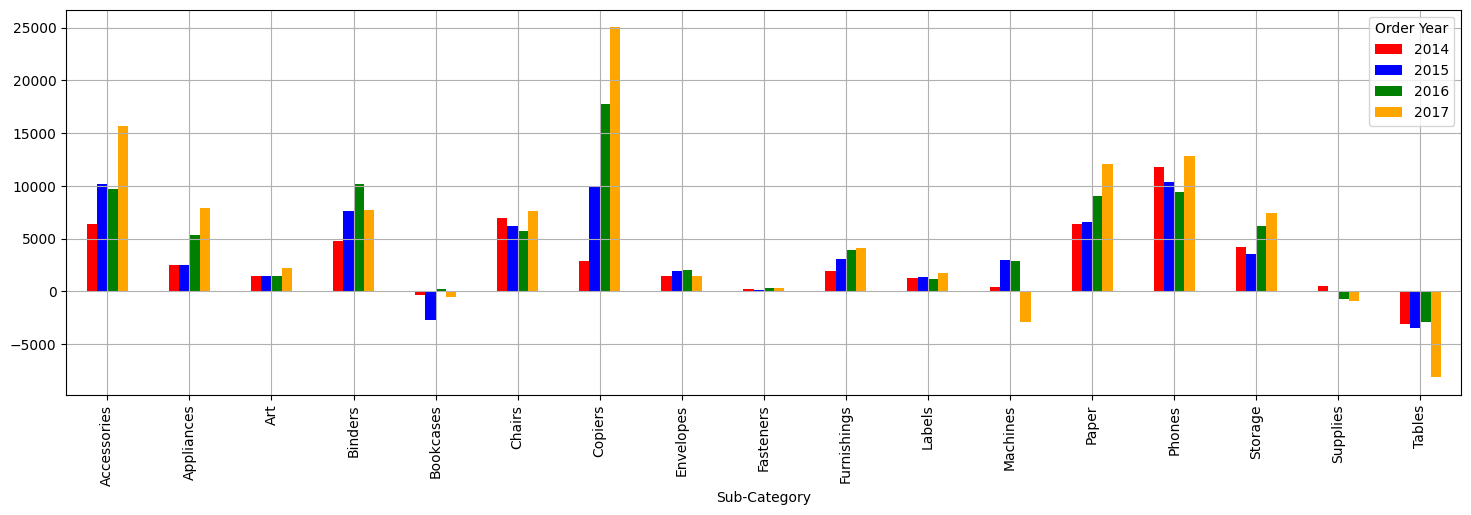

In [101]:
pivot_data = data.pivot_table(index='Sub-Category', columns='Order Year', values='Profit', aggfunc='sum')
pivot_data.plot(kind='bar',grid=True, figsize=(18,5),color=['red', 'blue', 'green', 'orange'])

In [102]:
data['Expenditure']=data['Sales']-data['Profit']

In [103]:
data.groupby('Order Year')[['Sales', 'Quantity', 'Expenditure', 'Profit']].sum()

,Sales,Quantity,Expenditure,Profit
Order Year,,,,
2014,484247.4981,7581,434703.5240,49543.9741
2015,470532.5090,7979,408913.9053,61618.6037
2016,609205.5980,9837,527410.4237,81795.1743
2017,733215.2552,12476,639775.9856,93439.2696


In [104]:
pivot = data.pivot_table(
    index='Sub-Category',
    columns='Order Year',
    values=['Sales', 'Profit', 'Quantity'],
    aggfunc='sum'
)
pivot = pivot.stack(level=1, future_stack=True)
pivot['Cost'] = pivot['Sales'] - pivot['Profit']

pivot['Cost_per_unit'] = pivot['Cost'] / pivot['Quantity']
pivot['Sales_per_unit'] = pivot['Sales'] / pivot['Quantity']
pivot['Profit_per_unit'] = pivot['Profit'] / pivot['Quantity']
pivot['Profit_margin'] = pivot['Profit'] / pivot['Sales']
pivot.sort_values('Profit_per_unit')

Profit  Quantity       Sales        Cost  \
Sub-Category Order Year                                                 
Machines     2017        -2869.2156       121  43544.6750  46413.8906   
Tables       2017        -8140.6947       390  60893.5425  69034.2372   
             2015        -3509.8019       235  39150.4235  42660.2254   
             2014        -3124.0427       270  46088.3655  49212.4082   
Bookcases    2015        -2755.2302       242  38543.5725  41298.8027   
...                             ...       ...         ...         ...   
Machines     2015         2977.4856        94  27763.6970  24786.2114   
Copiers      2014         2912.9433        29  10849.7820   7936.8387   
             2015         9930.2988        63  26179.4500  16249.1512   
             2016        17742.7926        69  49599.4100  31856.6174   
             2017        25031.7902        73  62899.3880  37867.5978   

                         Cost_per_unit  Sales_per_unit  Profit_per_unit  \
Sub-Category Order Year                                                   
Machines     2017           383.585873      359.873347       -23.712526   
Tables       2017           177.010865      156.137288       -20.873576   
             2015           181.532874      166.597547       -14.935327   
             2014           182.268179      170.697650       -11.570529   
Bookcases    2015           170.656210      159.270961       -11.385249   
...                                ...             ...              ...   
Machines     2015           263.683100      295.358479        31.675379   
Copiers      2014           273.684093      374.130414       100.446321   
             2015           257.923035      415.546825       157.623790   
             2016           461.690107      718.832029       257.141922   
             2017           518.734216      861.635452       342.901236   

                         Profit_margin  
Sub-Category Order Year                 
Machines     2017            -0.065891  
Tables       2017            -0.133687  
             2015            -0.089649  
             2014            -0.067784  
Bookcases    2015            -0.071484  
...                                ...  
Machines     2015             0.107244  
Copiers      2014             0.268479  
             2015             0.379317  
             2016             0.357722  
             2017             0.397966  

[68 rows x 8 columns]

In [105]:
pivot['Margin_Flag']= pivot['Profit_margin'].apply(lambda x: 'Loss' if x<0 else'Low' if x<0.1 else 'Good')
pivot

Profit  Quantity       Sales        Cost  \
Sub-Category Order Year                                                 
Accessories  2014         6402.7150       580  25014.2720  18611.5570   
             2015        10197.2752       635  40523.9600  30326.6848   
             2016         9664.2885       682  41895.8540  32231.5655   
             2017        15672.3570      1079  59946.2320  44273.8750   
Appliances   2014         2459.4999       314  15313.6250  12854.1251   
...                             ...       ...         ...         ...   
Supplies     2017         -955.3128       192  16049.4100  17004.7228   
Tables       2014        -3124.0427       270  46088.3655  49212.4082   
             2015        -3509.8019       235  39150.4235  42660.2254   
             2016        -2950.9418       346  60833.2005  63784.1423   
             2017        -8140.6947       390  60893.5425  69034.2372   

                         Cost_per_unit  Sales_per_unit  Profit_per_unit  \
Sub-Category Order Year                                                   
Accessories  2014            32.088891       43.128055        11.039164   
             2015            47.758559       63.817260        16.058701   
             2016            47.260360       61.430871        14.170511   
             2017            41.032322       55.557212        14.524891   
Appliances   2014            40.936704       48.769506         7.832802   
...                                ...             ...              ...   
Supplies     2017            88.566265       83.590677        -4.975587   
Tables       2014           182.268179      170.697650       -11.570529   
             2015           181.532874      166.597547       -14.935327   
             2016           184.347232      175.818499        -8.528734   
             2017           177.010865      156.137288       -20.873576   

                         Profit_margin Margin_Flag  
Sub-Category Order Year                             
Accessories  2014             0.255962        Good  
             2015             0.251636        Good  
             2016             0.230674        Good  
             2017             0.261440        Good  
Appliances   2014             0.160609        Good  
...                                ...         ...  
Supplies     2017            -0.059523        Loss  
Tables       2014            -0.067784        Loss  
             2015            -0.089649        Loss  
             2016            -0.048509        Loss  
             2017            -0.133687        Loss  

[68 rows x 9 columns]

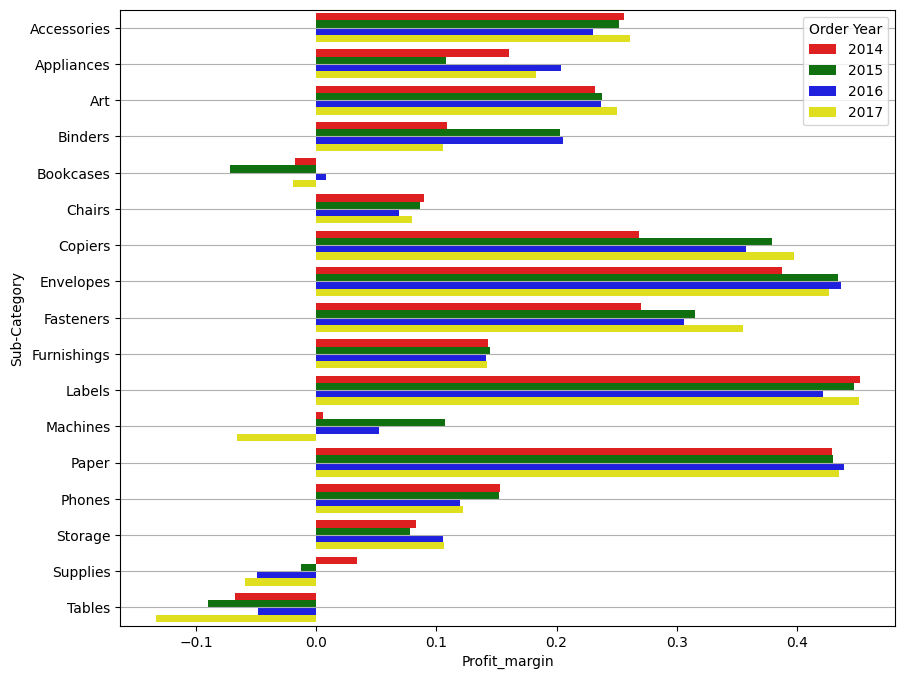

In [106]:
plt.figure(figsize=(10,8))
custom_palette = {
    2014: 'red',
    2015: 'green',
    2016: 'blue',
    2017: 'yellow'
}
sns.barplot(data=pivot, x='Profit_margin',y='Sub-Category',  hue='Order Year', palette = custom_palette)
plt.grid(axis='y')

In [107]:
without_low_prmar = data[~data['Sub-Category'].isin(['Bookcases', 'Supplies', 'Tables'])].groupby('Order Year')['Profit'].sum().round(2)
with_low_prmar = data.groupby('Order Year')['Profit'].sum().round(2)
comparison = pd.concat([with_low_prmar, without_low_prmar], axis=1)
comparison.columns = ['With_low_prmargin', 'Without_low_prmargin']
comparison['Change in %'] = ((comparison['Without_low_prmargin']-comparison['With_low_prmargin'])/comparison['With_low_prmargin']*100).round(2)
comparison

,With_low_prmargin,Without_low_prmargin,Change in %
Order Year,,,
2014,49543.97,52524.13,6.02
2015,61618.60,67908.51,10.21
2016,81795.17,85232.61,4.20
2017,93439.27,103118.90,10.36


In [108]:
data[(data['Sales']>data['Sales'].quantile(0.75)) & (data['Profit']<0)].groupby('Sub-Category').size().sort_values()

Sub-Category
Appliances       2
Supplies         8
Accessories     14
Furnishings     19
Binders         30
Machines        33
Phones          51
Storage         59
Bookcases       70
Chairs         149
Tables         149
dtype: int64

In [109]:
# From this we can see that the profit_margin of chairs in each year are positive even though this category has loss. However, we cannot say this explanation for tables since their huge 
#losses decreases this category profit_margin

Text(0.5, 1.0, 'Total Sales by Category')

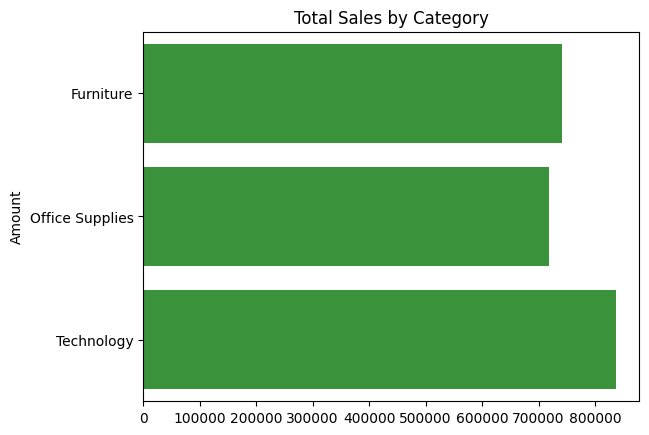

In [110]:
prof_sale_bycat = data.groupby('Category')[['Sales','Profit']].sum()
sns.barplot(x=prof_sale_bycat['Sales'].values, y=prof_sale_bycat.index, data=prof_sale_bycat , color='#2ca02c' )
plt.ylabel('Amount')
plt.title('Total Sales by Category')

In [134]:
month_year_pivot = data.pivot_table(index='Order Month', columns = 'Order Year', values=['Sales', 'Profit', 'Quantity'], aggfunc='sum')
month_year_pivot['Total Profit']=month_year_pivot['Profit'].sum(axis=1)
prof_plot = month_year_pivot['Profit'].reset_index().melt(id_vars='Order Month',var_name='Year',value_name='Profit')
sale_plot = month_year_pivot['Sales'].reset_index().melt(id_vars = 'Order Month',var_name='Year',value_name = 'Sales')
quan_plot = month_year_pivot['Quantity'].reset_index().melt(id_vars = 'Order Month',var_name='Year',value_name = 'Quantity')

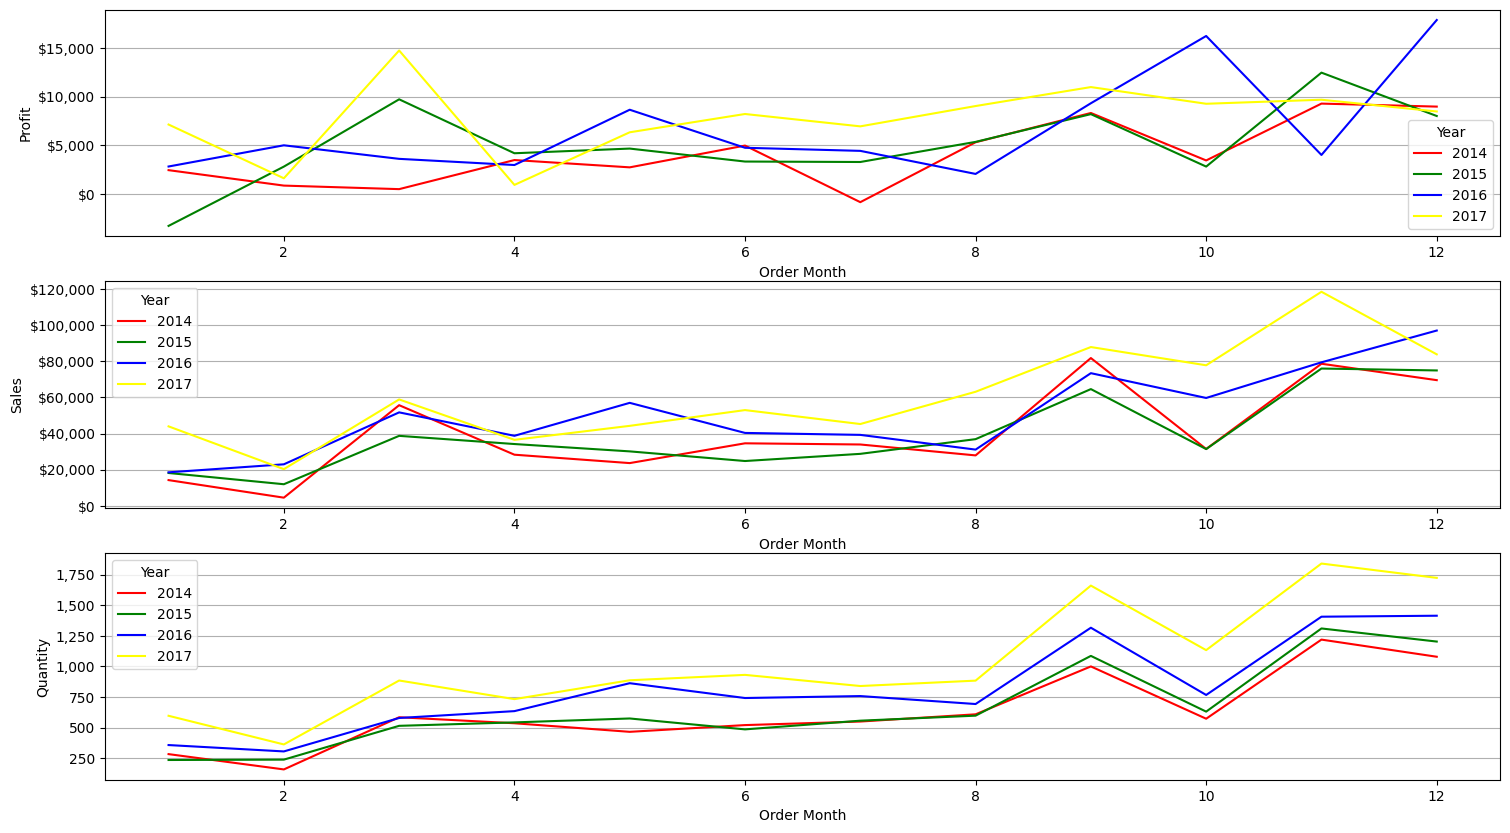

In [142]:
fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(18, 10))
sns.lineplot(data=prof_plot,x='Order Month',y='Profit',hue='Year', palette=custom_palette, ax=axes[0])
axes[0].grid(True, axis='y')
axes[0].set_label('Monthly Profit')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.lineplot(data=sale_plot,x='Order Month',y='Sales',hue='Year', palette=custom_palette, ax=axes[1])
axes[1].grid(True, axis='y')
axes[1].set_label('Monthly Sales')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.lineplot(data=quan_plot,x='Order Month',y='Quantity',hue='Year', palette=custom_palette, ax=axes[2])
axes[2].grid(True, axis='y')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[2].set_label('Monthly Quantity')

Text(0.5, 1.0, 'Total Profit by Customer Segment')

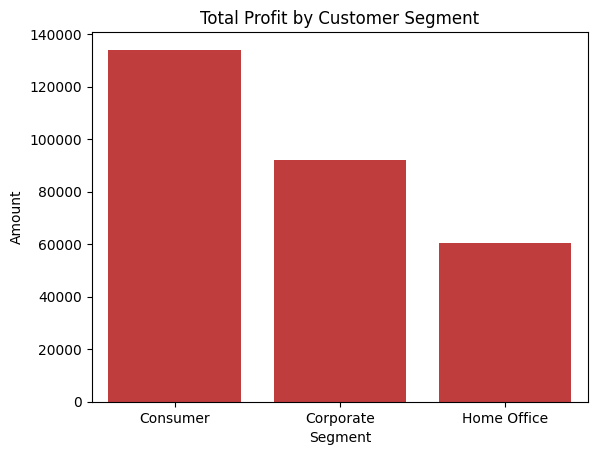

In [115]:
prof_byseg = data.groupby('Segment')[['Profit']].sum()
sns.barplot(data=prof_byseg , x=prof_byseg.index, y=prof_byseg['Profit'].values, color='#d62728')
plt.ylabel('Amount')
plt.title('Total Profit by Customer Segment')

<Axes: title={'center': 'AVG PROFIT/SALES FOR EACH DISCOUNT RATE'}, xlabel='Discount rate', ylabel='Amount'>

<Figure size 1000x500 with 0 Axes>

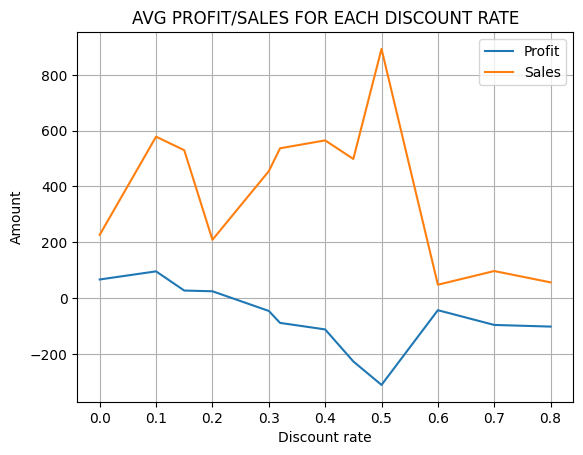

In [116]:
plt.figure(figsize =(10,5))
avgprof_discount = data.groupby('Discount')[['Profit', 'Sales',]].mean()
avgprof_discount.plot(
    kind='line', 
    grid=True, 
    xlabel = 'Discount rate', 
    ylabel='Amount', 
    title = 'AVG PROFIT/SALES FOR EACH DISCOUNT RATE')

In [117]:
sales_profit = data.pivot_table(index = 'Discount', columns = 'Order Year', values=['Profit','Sales', 'Quantity'], aggfunc='sum' )
sales_profit

Profit                                      Quantity        \
Order Year        2014        2015        2016         2017     2014  2015   
Discount                                                                     
0.00        58617.1665  68870.7566  89341.9679  104157.7122     3552  3877   
0.10         1285.0918   2392.4853   2051.0070    3300.5929       66   107   
0.15          109.0593    205.6139    566.7854     537.5329       44    42   
0.20        17576.5348  18554.9124  21192.5274   33013.3314     2866  2809   
0.30        -1981.4933  -2200.1043  -2320.0776   -3867.6022      184   174   
0.32         -130.1043   -796.3926   -972.4108    -492.2300        7    30   
0.40        -6869.7335  -5154.9761  -3199.1947   -7833.1461      173   151   
0.45         -110.7645   -616.6467   -537.2593   -1228.4406        3     9   
0.50        -5640.6087  -3887.0850  -4114.3461   -6864.3883       62    49   
0.60         -627.6601  -1051.8533  -2296.2641   -1968.8777      109   111   
0.70        -4167.4659 -10379.6350 -13457.5049  -12070.7511      279   362   
0.80        -8516.0480  -4318.4715  -4460.0559  -13244.4638      236   258   

                              Sales                                         
Order Year  2016  2017         2014         2015         2016         2017  
Discount                                                                    
0.00        4790  6048  214959.7300  226519.8500  297610.7400  348818.1500  
0.10         102    98    8721.8640   14100.7680   12589.3710   18957.3480  
0.15          41    71    4995.6030    5958.6785    7841.4455    8762.7945  
0.20        3505  4480  151245.0400  159970.0080  204064.3520  249314.9680  
0.30         232   259   26696.8730   18174.2610   27048.6230   31306.8980  
0.32          35    33     561.5916    4725.5920    5489.1640    3717.1112  
0.40         185   277   35263.9740   18469.8060   28583.9520   34100.0520  
0.45          18    15     174.0585    1524.5505    1276.7535    2509.6115  
0.50          66    64   31084.3650    6573.2550    7459.4750   13801.4450  
0.60         163   118     880.8960    1195.4400    2528.7320    2039.6320  
0.70         478   541    4879.4910   11352.6420   12330.6540   12057.4950  
0.80         222   472    4784.0120    1967.6580    2382.3360    7829.7500

In [118]:
profit_melted = sales_profit['Profit'].reset_index().melt(
    id_vars = 'Discount',
    var_name = 'Year',
    value_name = 'Profit'
)
sales_melted = sales_profit['Sales'].reset_index().melt(
    id_vars = 'Discount',
    var_name = 'Year',
    value_name = 'Sales'
)
quantity_melted = sales_profit['Quantity'].reset_index().melt(
    id_vars = 'Discount',
    var_name = 'Year',
    value_name = 'Quantity'
)

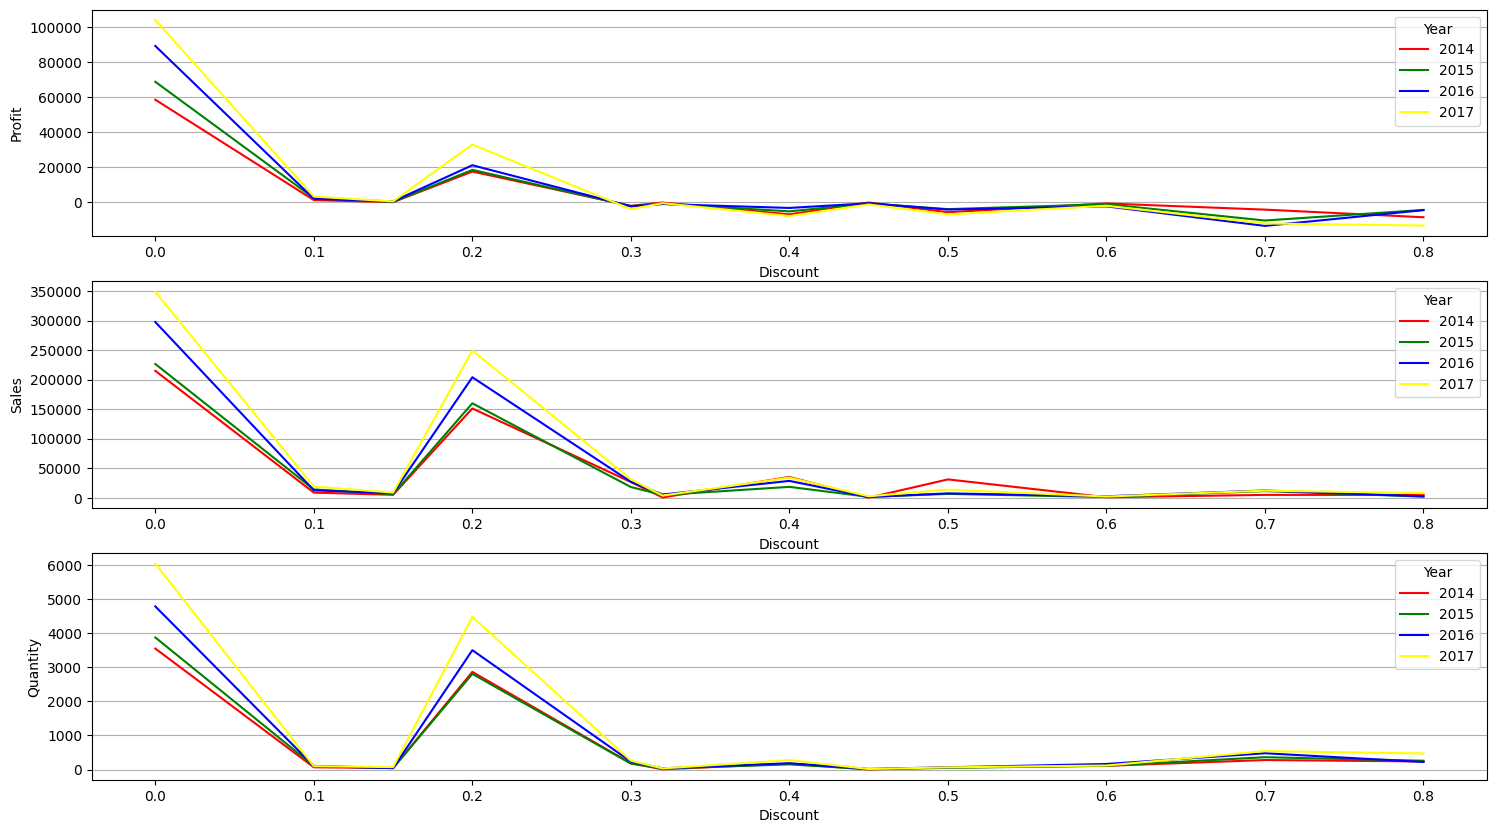

<Figure size 1800x500 with 0 Axes>

In [119]:
fig, axes = plt.subplots(figsize=(18,10), nrows=3, ncols=1)
plt.figure(figsize = (18,5))
sns.lineplot(data=profit_melted, x='Discount', y='Profit', hue='Year', palette=custom_palette, ax=axes[0])
axes[0].grid(True, axis='y')
sns.lineplot(data=sales_melted, x='Discount', y='Sales', hue='Year', palette=custom_palette, ax=axes[1])
axes[1].grid(True, axis='y')
sns.lineplot(data=quantity_melted, x='Discount', y='Quantity', hue='Year', palette=custom_palette, ax=axes[2])
axes[2].grid(True, axis='y')

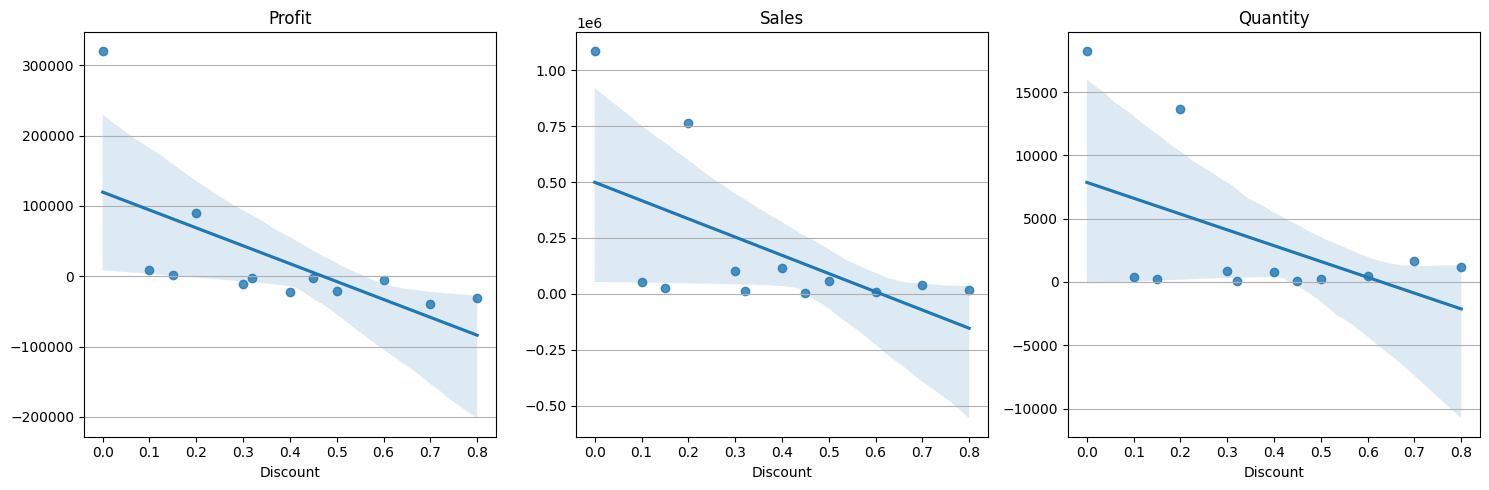

In [120]:
fig, axes = plt.subplots(nrows=1, ncols=3,figsize = (15, 5))
prof_sale_discount = data.groupby('Discount')[['Profit','Sales', 'Quantity']].sum()
sns.regplot(x=prof_sale_discount.index, y=prof_sale_discount['Profit'].values, data=prof_sale_discount, ax=axes[0])
axes[0].grid(True, axis='y')
axes[0].set_title('Profit')
sns.regplot(x=prof_sale_discount.index, y=prof_sale_discount['Sales'].values, data=prof_sale_discount, ax=axes[1])
axes[1].grid(True, axis='y')
axes[1].set_title('Sales')
sns.regplot(x=prof_sale_discount.index, y=prof_sale_discount['Quantity'].values, data=prof_sale_discount, ax=axes[2])
axes[2].grid(True, axis='y')
axes[2].set_title('Quantity')
plt.tight_layout()

In [121]:
discount = data.groupby('Discount')['Profit'].sum().sort_index()
loss_zone = data[data['Discount']>0.2]
loss_zone.shape # we can see that almost 14% of sales is located in loss zone

(1393, 28)

In [122]:
loss_zone.groupby('Order Year').size() # loss zone had increased year by year

Order Year
2014    282
2015    293
2016    363
2017    455
dtype: int64

In [123]:
loss_zone.groupby('Order Year')['Profit'].sum()

Order Year
2014   -28043.8783
2015   -28405.1645
2016   -31357.1134
2017   -47569.8998
Name: Profit, dtype: float64

## Recomendation

In [1]:
# 1. From the charts, we can see that the most significant losses came from Tables, Supplies, and Bookcases. If we look at their profit margins, 
#    they have been negative for almost all of the past 4 years. 
#    During 2014-2016, the company's annual profit margin increased, but it decreased in 2017 by 0.3%. This means that the overall annual profit 
#    increased mainly due to an increased sales volume. 
#    I recommend either dropping Tables, Bookcases, and Supplies from the product line or finding cheaper ways for their production and logistics. 
#    By solving this issue, the company can prevent an annual profit loss of around 8%.

# 2. If we look at the Total Profit and Total Sales for each discount rate, we can observe that the profit becomes negative when the discount rate is
#    more than 25%. 
#    Moreover, most of the profit came from sales where the offered discount rate was exactly 0% or 20%. 
#    Therefore, I suggest keeping the maximum discount rate at 25% unless there is an exceptionally important contract.